# Hierarchical Clustering – Customer Usage Patterns

## Problem Statement

**Can we discover how customers are related based on their usage patterns?**

### Objective
Use **Hierarchical (Agglomerative) Clustering** to discover groups of customers with similar usage patterns.

This notebook focuses only on Hierarchical Clustering.


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 1: Load the Dataset

In [2]:
file_path = r"C:\Users\hp\Desktop\calibo\Supervised_Learning_Messy_Customer_Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (184, 13)


## Step 2: View the Dataset

In [3]:
display(df.head())


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


## Step 3: Understand the Dataset

Check:
- Shape
- Columns
- Data types
- Basic statistics


In [4]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nStatistical summary:")
display(df.describe(include="all").T)


Shape: (184, 13)

Column names:
['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']

Data types:
Customer_ID                  str
Age                      float64
Annual_Income                str
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,184,180,CUST-1043,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,176.0,NaN,NaN,NaN,36.164773,12.865951,-5.0,29.0,36.0,41.0,145.0
Annual_Income,173,156,76600.0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure_Months,177.0,NaN,NaN,NaN,39.39548,21.545185,1.0,25.0,38.0,55.0,150.0
Monthly_Charges,178.0,NaN,NaN,NaN,80.205899,74.17937,0.0,57.885,73.565,90.28,999.0
Support_Calls_Last_3M,179.0,NaN,NaN,NaN,3.217877,2.577455,0.0,2.0,3.0,4.0,30.0
Data_Usage_GB,178.0,NaN,NaN,NaN,17.80618,9.245516,-10.0,11.6,18.2,24.2,44.0
Satisfaction_Score,178.0,NaN,NaN,NaN,5.803371,2.947869,1.0,4.0,6.0,8.0,15.0
Contract_Type,184,8,Monthly,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,184,9,Bank Transfer,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4: Check Missing Values

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])


Missing values in each column:
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
dtype: int64


## Step 5: Check Duplicate Records

In [6]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)


Duplicate rows: 4


## Step 6: Remove Duplicate Records

In [7]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (180, 13)


## Step 7: Exploratory Data Analysis – Correlation Heatmap

The correlation heatmap is used to understand the relationships between numerical customer features before clustering.


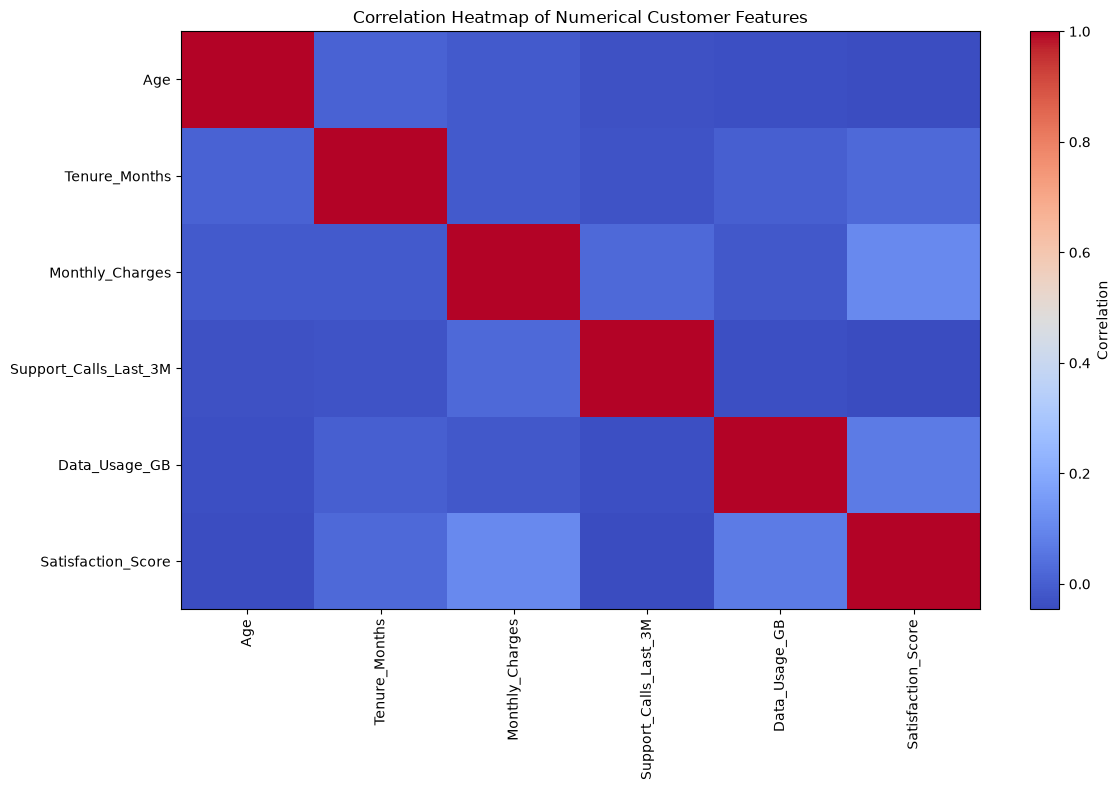

In [8]:
# Correlation Heatmap

numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Numerical Customer Features")
plt.tight_layout()
plt.show()


## Step 7: Exploratory Data Analysis – Box Plots

Box plots are used to understand the distribution of numerical features and identify possible extreme values.


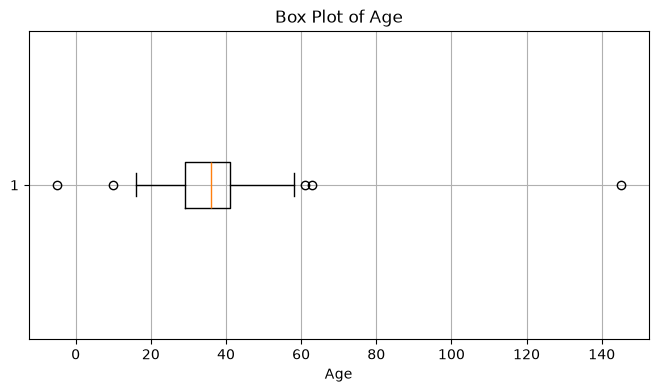

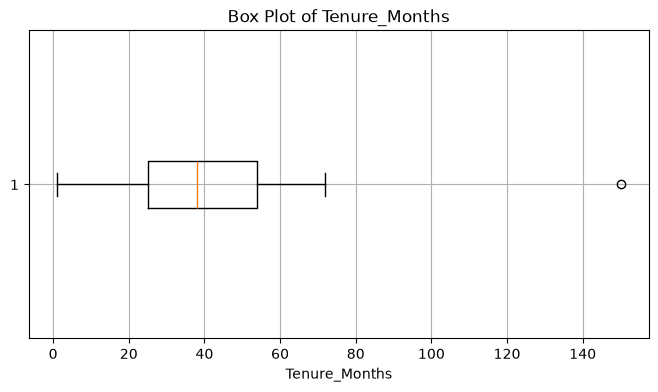

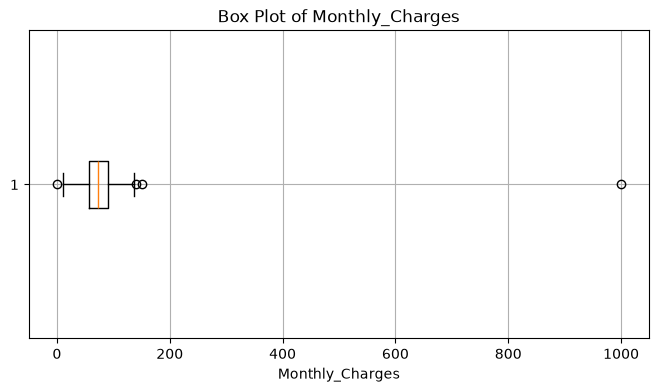

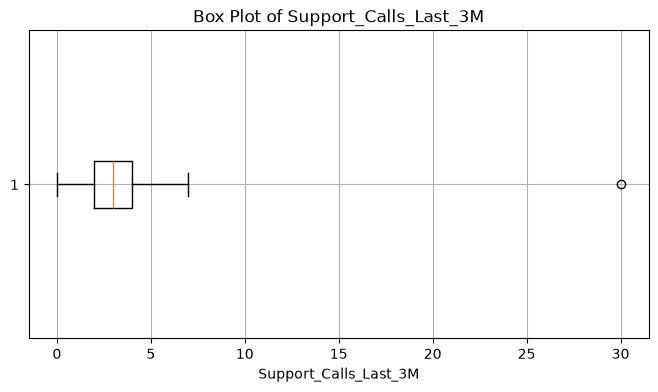

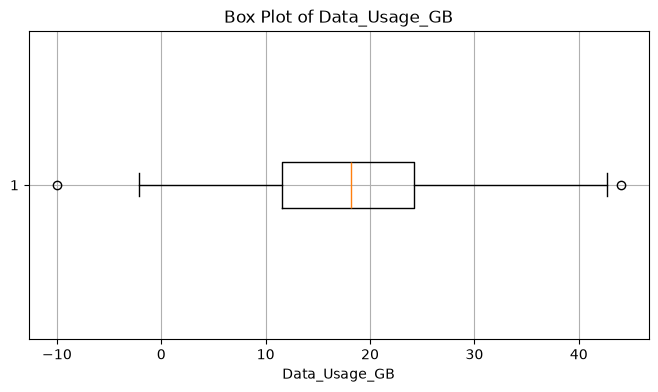

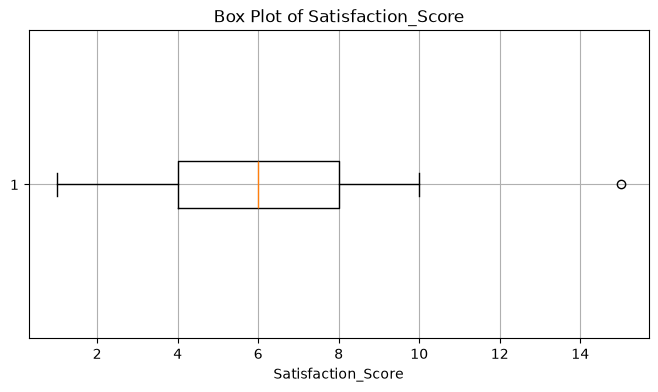

In [9]:
# Box Plots for Numerical Features

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.xlabel(column)
    plt.title(f"Box Plot of {column}")
    plt.grid(True)

    plt.show()


## Step 8: Outlier Detection using IQR

The Interquartile Range (IQR) method is used to identify possible outliers.

- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR


In [10]:
# Outlier Detection using IQR

outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": int(outlier_count)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary.round(2))


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,29.00,41.00,12.00,11.0,59.00,5
1,Tenure_Months,25.00,54.00,29.00,-18.5,97.50,1
2,Monthly_Charges,57.46,90.03,32.57,8.6,138.89,4
3,Support_Calls_Last_3M,2.00,4.00,2.00,-1.0,7.00,1
4,Data_Usage_GB,11.60,24.20,12.60,-7.3,43.10,2
5,Satisfaction_Score,4.00,8.00,4.00,-2.0,14.00,1


## Step 9: Handle Outliers using IQR Capping

Instead of deleting customers, extreme numerical values are capped at the IQR boundaries. This keeps all customer records while reducing the effect of extreme values on distance-based clustering.


In [11]:
# Handle Outliers using IQR Capping

df_clean = df.copy()

for column in numerical_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[column] = df_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outliers handled using IQR capping.")


Outliers handled using IQR capping.


## Step 10: Use the Cleaned Dataset

The cleaned dataset is used for the remaining preprocessing and clustering steps.


In [12]:
# Continue the workflow with the cleaned data

df = df_clean.copy()

print("Dataset shape after EDA and outlier handling:", df.shape)
print("Missing values:", df.isnull().sum().sum())


Dataset shape after EDA and outlier handling: (180, 13)
Missing values: 49


## Step 11: Remove Unnecessary Columns

- `Customer_ID` is an identifier, so it is not useful for measuring customer similarity.
- `Churn` is a target/label and is not used because this is an unsupervised learning problem.


In [13]:
columns_to_drop = []

if "Customer_ID" in df.columns:
    columns_to_drop.append("Customer_ID")

if "Churn" in df.columns:
    columns_to_drop.append("Churn")

df_model = df.drop(columns=columns_to_drop, errors="ignore").copy()

print("Removed columns:", columns_to_drop)
print("Shape after removing unnecessary columns:", df_model.shape)


Removed columns: ['Customer_ID', 'Churn']
Shape after removing unnecessary columns: (180, 11)


## Step 12: Convert Annual Income to Numeric

In [14]:
if "Annual_Income" in df_model.columns:
    df_model["Annual_Income"] = (
        df_model["Annual_Income"]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )

    df_model["Annual_Income"] = pd.to_numeric(
        df_model["Annual_Income"],
        errors="coerce"
    )

print(df_model.dtypes)


Age                      float64
Annual_Income            Float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
dtype: object


## Step 13: Identify Numerical and Categorical Features

In [15]:
numerical_features = df_model.select_dtypes(include=np.number).columns.tolist()
categorical_features = df_model.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical features:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']


## Step 14: Handle Missing Values

In [16]:
# Fill numerical missing values with median
for column in numerical_features:
    df_model[column] = df_model[column].fillna(df_model[column].median())

# Fill categorical missing values with mode
for column in categorical_features:
    mode_value = df_model[column].mode(dropna=True)
    if not mode_value.empty:
        df_model[column] = df_model[column].fillna(mode_value.iloc[0])

print("Total missing values after handling:", df_model.isnull().sum().sum())


Total missing values after handling: 0


## Step 15: Select Customer Usage Features

The main usage-pattern features are selected first.

These features help describe how customers use the service:
- Monthly Charges
- Data Usage
- Support Calls
- Tenure

Other useful numerical customer attributes available in the dataset can also be included.


In [17]:
preferred_usage_features = [
    "Monthly_Charges",
    "Data_Usage_GB",
    "Support_Calls_Last_3M",
    "Tenure_Months",
    "Age",
    "Satisfaction_Score",
    "Annual_Income"
]

selected_features = [
    column for column in preferred_usage_features
    if column in df_model.columns
]

print("Selected features for customer relationship analysis:")
print(selected_features)


Selected features for customer relationship analysis:
['Monthly_Charges', 'Data_Usage_GB', 'Support_Calls_Last_3M', 'Tenure_Months', 'Age', 'Satisfaction_Score', 'Annual_Income']


## Step 16: Prepare Data for Encoding

In [18]:
model_input = df_model[
    selected_features + categorical_features
].copy()

print("Shape before encoding:", model_input.shape)


Shape before encoding: (180, 11)


## Step 17: Encode Categorical Features

In [19]:
X = pd.get_dummies(
    model_input,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X.shape)

print("\nRemaining categorical columns:")
print(
    X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
)


Shape after encoding: (180, 34)

Remaining categorical columns:
[]


## Step 18: Final Data Cleaning Before Scaling

In [20]:
# Replace infinite values with missing values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill any remaining missing values
for column in X.columns:
    if X[column].isnull().any():
        X[column] = X[column].fillna(X[column].median())

print("Total missing values:", X.isnull().sum().sum())
print("Total infinite values:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())


Total missing values: 0
Total infinite values: 0


## Step 19: Feature Scaling

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")
print("Scaled data shape:", X_scaled.shape)


Feature scaling completed.
Scaled data shape: (180, 34)


## Step 20: Final Data Validation

In [22]:
print("Shape:", X_scaled.shape)
print("Total missing values:", np.isnan(X_scaled).sum())
print("Total infinite values:", np.isinf(X_scaled).sum())
print("Number of features:", X_scaled.shape[1])


Shape: (180, 34)
Total missing values: 0
Total infinite values: 0
Number of features: 34


## Step 21: Create the Hierarchical Linkage Matrix

Ward linkage is used to build the hierarchy of customers based on their scaled usage patterns.


In [23]:
linkage_matrix = linkage(
    X_scaled,
    method="ward"
)

print("Linkage matrix created successfully.")
print("Linkage matrix shape:", linkage_matrix.shape)


Linkage matrix created successfully.
Linkage matrix shape: (179, 4)


## Step 22: Plot the Dendrogram

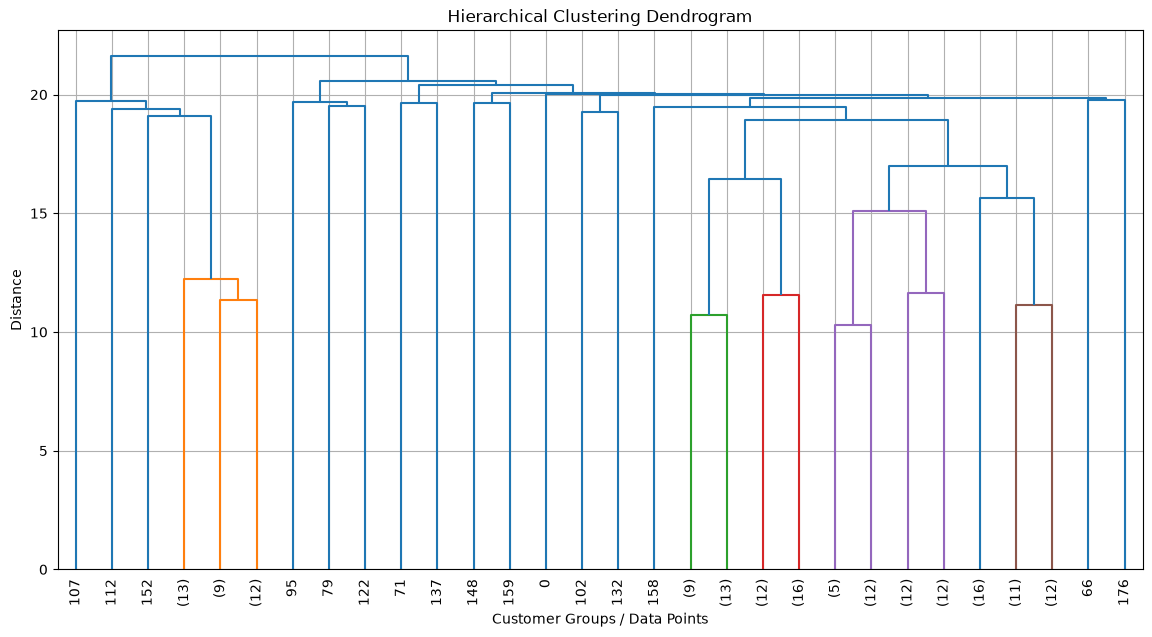

In [24]:
plt.figure(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups / Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


## Step 23: Test Different Numbers of Clusters

Silhouette Score is used to compare different cluster counts.


In [25]:
cluster_range = range(2, 9)
silhouette_scores = []

for n_clusters in cluster_range:
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"Clusters = {n_clusters}, "
        f"Silhouette Score = {score:.4f}"
    )


Clusters = 2, Silhouette Score = 0.0352
Clusters = 3, Silhouette Score = 0.0456
Clusters = 4, Silhouette Score = 0.0528
Clusters = 5, Silhouette Score = 0.0598
Clusters = 6, Silhouette Score = 0.0648
Clusters = 7, Silhouette Score = 0.0719
Clusters = 8, Silhouette Score = 0.0790


## Step 24: Visualize Silhouette Scores

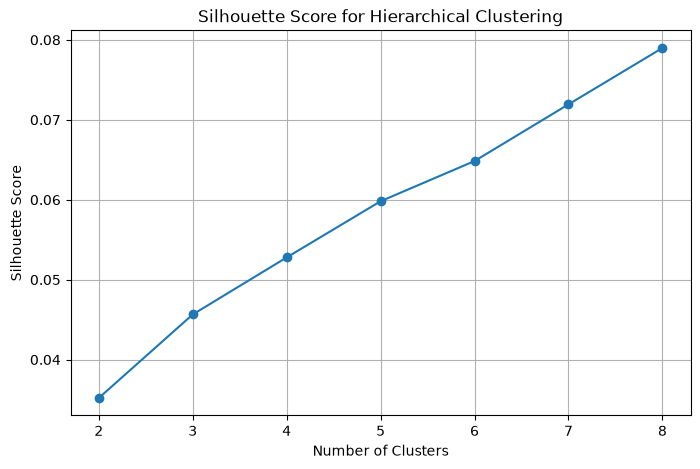

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(cluster_range),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Hierarchical Clustering")
plt.xticks(list(cluster_range))
plt.grid(True)
plt.show()


## Step 25: Select the Number of Clusters

In [27]:
best_index = int(np.argmax(silhouette_scores))

best_n_clusters = list(cluster_range)[best_index]
best_silhouette = silhouette_scores[best_index]

print("Selected number of clusters:", best_n_clusters)
print("Best Silhouette Score:", round(best_silhouette, 4))


Selected number of clusters: 8
Best Silhouette Score: 0.079


## Step 26: Train the Final Hierarchical Clustering Model

In [28]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=best_n_clusters,
    linkage="ward"
)

cluster_labels = hierarchical_model.fit_predict(X_scaled)

print("Final Hierarchical Clustering model trained successfully.")


Final Hierarchical Clustering model trained successfully.


## Step 27: Add Cluster Labels to Customer Data

In [29]:
df_clustered = df_model.copy()

df_clustered["Cluster"] = cluster_labels

display(df_clustered.head())


,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Cluster
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,5
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,1
2,55.0,64400.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,7
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,1
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,7


## Step 28: Count Customers in Each Cluster

In [30]:
cluster_counts = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers in each cluster:")
print(cluster_counts)


Customers in each cluster:
Cluster
0      2
1     37
2      3
3      2
4      2
5      1
6      2
7    131
Name: count, dtype: int64


## Step 29: Calculate Final Silhouette Score

In [31]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print(
    "Final Silhouette Score:",
    round(final_silhouette, 4)
)


Final Silhouette Score: 0.079


## Step 30: Analyze Customer Usage Patterns by Cluster

Calculate the average values of the main usage features for each cluster.


In [32]:
usage_features = [
    "Monthly_Charges",
    "Data_Usage_GB",
    "Support_Calls_Last_3M",
    "Tenure_Months"
]

available_usage_features = [
    column for column in usage_features
    if column in df_clustered.columns
]

usage_profile = (
    df_clustered[
        available_usage_features + ["Cluster"]
    ]
    .groupby("Cluster")
    .mean(numeric_only=True)
)

display(usage_profile.round(2))


,Monthly_Charges,Data_Usage_GB,Support_Calls_Last_3M,Tenure_Months
Cluster,,,,
0,65.67,24.70,2.50,38.00
1,69.92,21.15,3.24,41.57
2,84.06,10.67,3.33,28.67
3,94.06,11.80,2.00,33.50
4,76.12,17.80,2.50,47.50
5,62.96,20.40,7.00,11.00
6,57.69,19.95,2.50,39.00
7,76.21,16.99,3.04,38.64


## Step 31: Cluster Size Summary

In [33]:
cluster_summary = pd.DataFrame({
    "Customer_Count": cluster_counts
})

cluster_summary["Percentage"] = (
    cluster_summary["Customer_Count"]
    / len(df_clustered)
    * 100
)

display(cluster_summary.round(2))


,Customer_Count,Percentage
Cluster,,
0,2,1.11
1,37,20.56
2,3,1.67
3,2,1.11
4,2,1.11
5,1,0.56
6,2,1.11
7,131,72.78


## Step 32: Visualize Customer Distribution

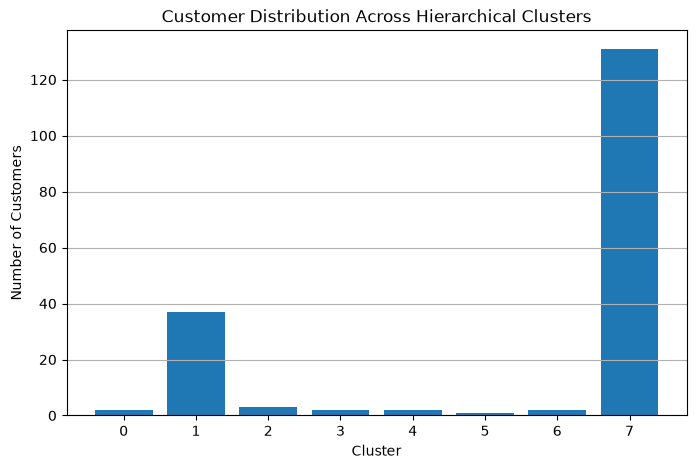

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution Across Hierarchical Clusters")
plt.grid(axis="y")
plt.show()


## Step 33: PCA for Cluster Visualization

PCA is used only to visualize the final hierarchical clusters in two dimensions.


In [35]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)


Explained variance ratio: [0.06016614 0.05464262]
Total explained variance: 0.1148


## Step 34: Visualize Customer Relationships

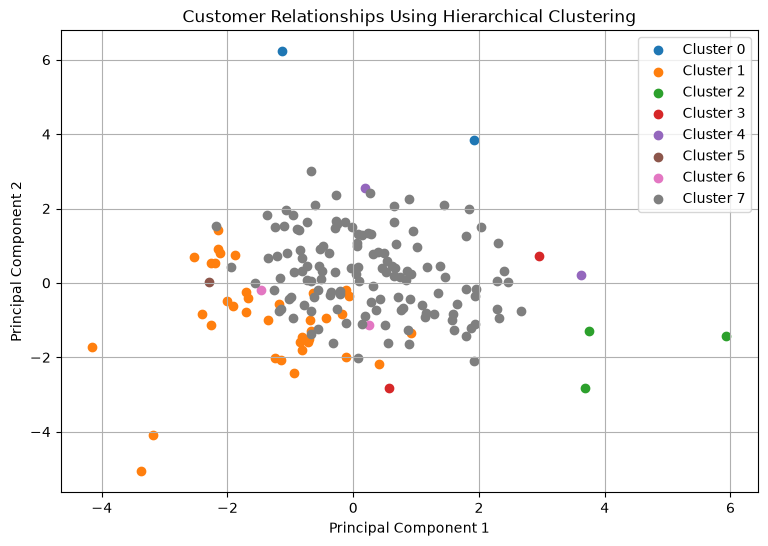

In [36]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "Customer Relationships Using Hierarchical Clustering"
)
plt.legend()
plt.grid(True)
plt.show()


## Step 35: Business Interpretation

The clusters represent groups of customers with similar usage patterns.

For each cluster, compare:
- Monthly Charges
- Data Usage
- Support Calls
- Tenure

Customers within the same cluster have relatively similar characteristics based on the features used for clustering.


## Step 36: Final Results

In [37]:
print("=" * 60)
print("FINAL HIERARCHICAL CLUSTERING RESULTS")
print("=" * 60)

print("\nProblem Statement:")
print(
    "Can we discover how customers are related "
    "based on their usage patterns?"
)

print("\nSelected Number of Clusters:", best_n_clusters)
print("Final Silhouette Score:", round(final_silhouette, 4))

print("\nCustomers in Each Cluster:")
print(cluster_counts)

print("\nCustomer Usage Profile:")
display(usage_profile.round(2))


FINAL HIERARCHICAL CLUSTERING RESULTS

Problem Statement:
Can we discover how customers are related based on their usage patterns?

Selected Number of Clusters: 8
Final Silhouette Score: 0.079

Customers in Each Cluster:
Cluster
0      2
1     37
2      3
3      2
4      2
5      1
6      2
7    131
Name: count, dtype: int64

Customer Usage Profile:


,Monthly_Charges,Data_Usage_GB,Support_Calls_Last_3M,Tenure_Months
Cluster,,,,
0,65.67,24.70,2.50,38.00
1,69.92,21.15,3.24,41.57
2,84.06,10.67,3.33,28.67
3,94.06,11.80,2.00,33.50
4,76.12,17.80,2.50,47.50
5,62.96,20.40,7.00,11.00
6,57.69,19.95,2.50,39.00
7,76.21,16.99,3.04,38.64


## Step 37: Conclusion

Hierarchical Clustering was used to discover how customers are related based on their usage patterns.

The dataset was cleaned, unnecessary columns were removed, categorical variables were encoded, and features were scaled. A dendrogram was used to understand the hierarchical relationships between customers. The final clusters were evaluated using the Silhouette Score and analyzed using average usage patterns.

Thus, Hierarchical Clustering helps identify groups of customers with similar usage behavior.
